In [1]:
import numpy as np
import matplotlib.pyplot as plt

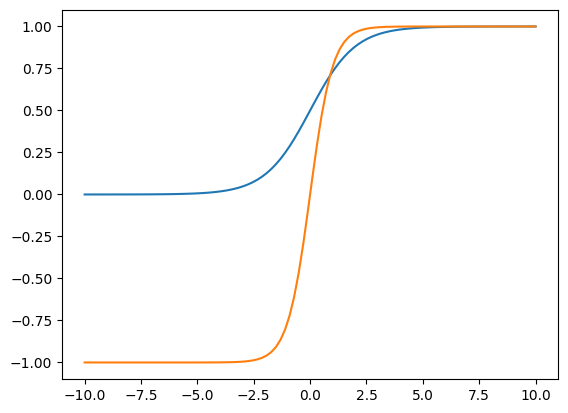

In [11]:
def sigmoid(x): return 1 / (1 + np.exp(-x))
x = np.linspace(start = -10, stop = 10, num = 100) # 1D np array with 100 entries
y = sigmoid(x)
z = np.tanh(x)
plt.figure() # creates blank canvas
plt.plot(x, y) # important: len(x) == len(y)
plt.plot(x, z)
plt.show()

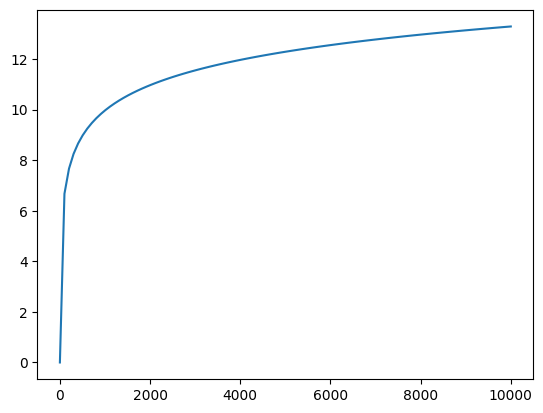

In [3]:
x = np.linspace(start = 1, stop = 10000, num = 100)
y = np.log2(x)
plt.figure() # creates blank canvas
plt.plot(x, y)
plt.show()

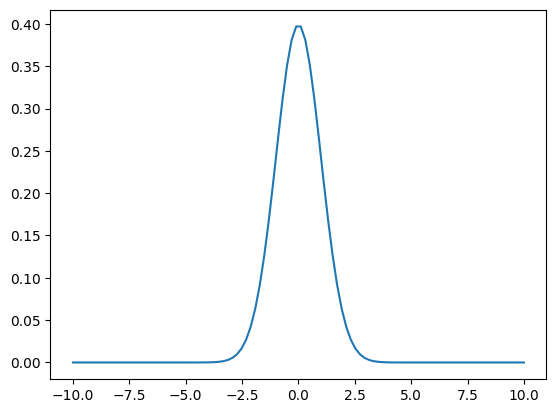

In [4]:
mu, sigma = 0, 1
def gauss(x): return (1/(np.sqrt(2*np.pi*sigma**2))) * np.exp(-(x-mu)**2/(2*sigma**2))
n = np.linspace(start = -10, stop = 10, num = 100)

plt.figure()
plt.plot(n, gauss(n))

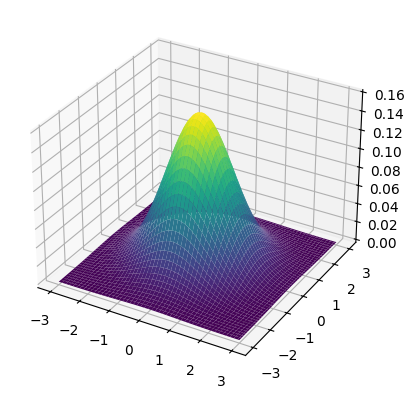

In [5]:
from scipy.stats import multivariate_normal

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

pos = np.dstack((X, Y))
Z = multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]]).pdf(pos)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
plt.show()

# **Coffee Cup**

In [6]:
def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_derifitive(x): return x * (1 - x)

# XOR dataset
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])
w1 = np.random.randn(2,2) # Layer 1: weight matrix
w2 = np.random.randn(2,1) # Layer 2: weight vector

def training_network(X, y, w1, w2, alpha):
  train_error = []
  for _ in range(50000):
    hidden_layer_input = X @ w1
    hidden_layer_output = sigmoid(hidden_layer_input)

    output_layer_input = hidden_layer_output @ w2
    pred = sigmoid(output_layer_input)

    # MSE is used here, but never written explicitly
    error = y - pred
    train_error.append(np.mean(np.abs(error))) # .mean() turns error matrix into scalar
    d_pred = error * sigmoid_derifitive(pred)
    error_hidden = d_pred @ w2.T
    d_hidden = error_hidden * sigmoid_derifitive(hidden_layer_output)
    w2 += hidden_layer_output.T @ d_pred * alpha
    w1 += X.T @ d_hidden * alpha

  plt.figure
  plt.plot(train_error)
  plt.show()

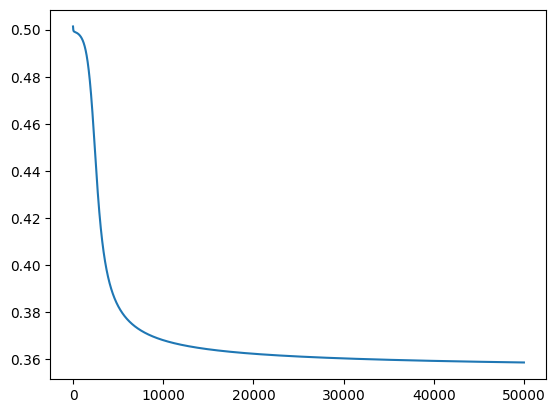

In [7]:
w1 = np.random.randn(2,2) # Layer 1: weight matrix
w2 = np.random.randn(2,1) # Layer 2: weight vector
training_network(X, y, w1, w2, 0.2)

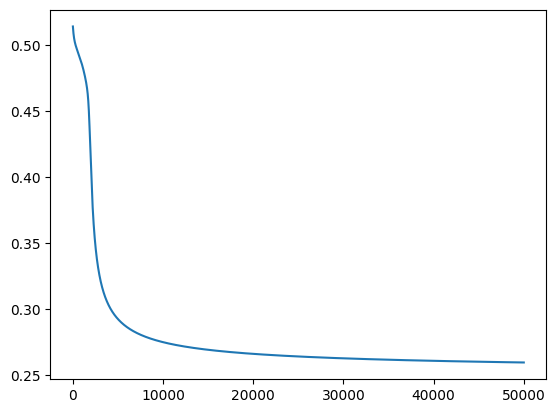

In [8]:
w1 = np.random.randn(2, 2) * 2
w2 = np.random.randn(2, 1) * 2
training_network(X, y, w1, w2, 0.2)

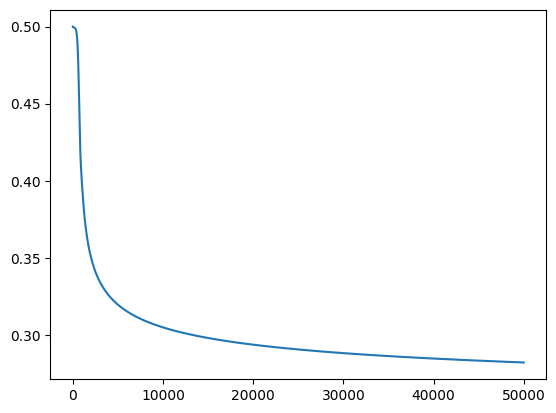

In [9]:
w1 = np.random.randn(2,2) # Layer 1: weight matrix
w2 = np.random.randn(2,1) # Layer 2: weight vector
training_network(X, y, w1, w2, 1)

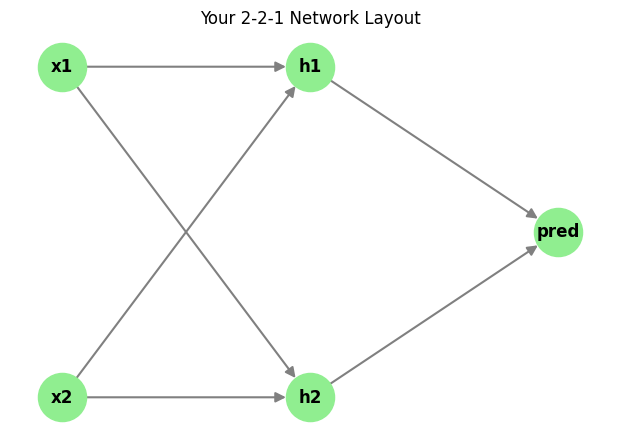

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create a directed graph and manually map the 2-2-1 connections
G = nx.DiGraph([
    ('x1', 'h1'), ('x1', 'h2'),
    ('x2', 'h1'), ('x2', 'h2'),
    ('h1', 'pred'), ('h2', 'pred')
])

# 2. Hardcode the simple grid coordinates for a perfect layout
pos = {
    'x1': (0, 1), 'x2': (0, -1),      # Input column (x=0)
    'h1': (1, 1), 'h2': (1, -1),      # Hidden column (x=1)
    'pred': (2, 0)                     # Output column (x=2)
}

# 3. Draw it beautifully
plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, node_size=1200, node_color='lightgreen',
        font_weight='bold', arrowsize=15, width=1.5, edge_color='gray')
plt.title("Your 2-2-1 Network Layout")
plt.axis('off')
plt.show()